# BigQuery のデータを用いたビジネス分析 AI エージェント

このノートブックでは、BigQuery に保存された e-コマースサイトのビジネスデータを分析する AI エージェントを実装します。

特に、保存データの構造や利用方法をまとめた「ナレッジベース」を用いて、データ分析におけるハルシネーションを回避する方法を説明します。このナレッジベースは、一般に、データベースの「セマンティックレイヤー」に相当します。


## 事前準備

**[BAA-01]**

ADK と Gemini API の利用に必要なパッケージをインストールします。

ADK は開発の速度が速く、後方互換性のない機能変更が行われることがあります。ここでは、安全のために動作確認ができたバーションを指定してインストールしています。

**最後に `RESTART SESSION` ボタンが表示された場合は、これをクリックしてセッションを再起動してください。**

**注意**: `ERROR: pip's dependency resolver does not currently take into account...` のようなエラーメッセージが表示される場合がありますが、これは無視して構いません。

In [ ]:
%pip install --upgrade --user \
    google-adk==2.9.2 \
    google-cloud-aiplatform==2.1.3 \
    google-cloud-dataplex==2.20.0 \
    google-genai==2.24.0 \
    vl-convert-python==1.9.0.post1 \
    pillow==12.3.0

**[BAA-02]**

インストールされたパッケージのバージョンを確認します。

In [1]:
!pip list | grep -E "(google-adk|google-genai|google-cloud-aiplatform|google-cloud-dataplex|vl-convert-python|pillow)"

google-adk                            2.9.2
google-cloud-aiplatform               2.1.3
google-cloud-dataplex                 2.20.0
google-genai                          2.24.0
pillow                                12.3.0
vl-convert-python                     1.9.0.post1


下記の内容が出力されたことを確認してください。

```
google-adk                            2.9.2
google-cloud-aiplatform               2.1.3
google-cloud-dataplex                 2.20.0
google-genai                          2.24.0
pillow                                12.3.0
vl-convert-python                     1.9.0.post1
```

## ユーザー認証

**[BAA-03]**

変数 `PROJECT_ID` に事前に準備したプロジェクトのプロジェクト ID を指定してください。

**注意**: プロジェクトを作成したユーザーアカウントと Colab を使用中のユーザーアカウントが一致している必要があります。


In [ ]:
###
PROJECT_ID = 'Project ID を入力'
###

if (not PROJECT_ID) or PROJECT_ID == 'Project ID を入力':
    print('Gemini API を使用する Google Cloud Project の Project ID を入力してください。')
else:
    print(f'変数 PROJECT_ID を設定しました。')
    print(f'PROJECT_ID = {PROJECT_ID}')

**[BAA-04]**

Google Cloud のプロジェクトを使用するためのユーザー認証を行います。

ポップアップ画面の指示に従って、認証処理を行ってください。

許可する操作を選択するチェックボックスが表示された場合は、すべてにチェックを入れてください。

In [4]:
from google.colab import auth
auth.authenticate_user(project_id=PROJECT_ID)

## 初期設定

**[BAA-05]**

この後の作業に必要なモジュールをインポートして、LlmAgent オブジェクトが参照する環境変数を設定します。あわせて、アーティファクトを保存するクラウドストレージのバケットを作成します。

In [5]:
import base64, copy, json, io, os, re, urllib, uuid
import vl_convert as vlc
from PIL import Image
from IPython.display import Markdown, display
import agentplatform
from agentplatform.frameworks import AdkApp
from google import auth
from google.genai.types import (
    Content, HttpOptions, HttpRetryOptions,
    Part, ThinkingConfig, ThinkingLevel,
)
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.models.google_llm import Gemini
from google.adk.integrations.bigquery import BigQueryCredentialsConfig, BigQueryToolset
from google.adk.integrations.bigquery.config import BigQueryToolConfig, WriteMode
from google.adk.planners import BuiltInPlanner
from google.adk.plugins.save_files_as_artifacts_plugin import SaveFilesAsArtifactsPlugin
from google.adk.tools import ToolContext
from google.adk.tools.agent_tool import AgentTool

agentplatform.init(project=PROJECT_ID, location='us-central1')
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l us-central1 gs://{BUCKET_NAME}

gs://adk-development2_artifacts/


**[BAA-06]**

AdkApp オブジェクトとの会話を行う簡易的なアプリケーションのクラス ChatClient を定義します。

In [6]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

**[BAA-07]**

「日本語テキスト出力時のマークダウン表示崩れの防止ルール」と Gemini API のモデル選択をテンプレートとして用意しておきます。

In [7]:
markdown_rule = r'''
# 日本語テキスト出力時のマークダウン表示崩れの防止ルール
マークダウンの修飾記号（太字 `**` や斜体 `*` など）と、日本語の特殊記号や全角文字が隣り合うことで生じる表示崩れを防ぐため、以下のルールを厳守してください。

## 1. 記号と太字の間にスペースを入れる基本ルール
太字記号（`**`）の直前・直後に、鉤括弧や丸括弧、その他の記号が来る場合は、必ず半角スペースを1つ挟んでください。

- **全角鉤括弧（「」）：**
  - 【NG例】`**「重要」**なポイント`
  - 【OK例】`**「重要」** なポイント`
- **全角・半角の丸括弧（（） / ()）：**
  - 【NG例】`**（注意）**事項です`
  - 【OK例】`**（注意）** 事項です`
- **パーセント（% / ％）や数値・単位：**
  - 【NG例】`達成率は**100%**です`
  - 【OK例】`達成率は **100%** です`

## 2. 記号自体のエスケープと厳禁な組み合わせ
- マークダウンの特殊文字として誤認されやすい半角記号（`*`, `_`, `~`, `\` など）をそのまま表示する場合は、隣接するアスタリスク等との間にスペースを設けてください。
- アンダースコア（`_`）は単語の途中の日本語や全角文字と混ざると強力なイタリック・太字パーサに拾われやすいため、強調用以外では原則として直接隣接させないでください。

## 3. 通貨記号 `$` のエスケープ
- 通貨記号 `$` は数式の開始と誤認されないようにエスケープして出力してください。
  - 【NG例】`$100`
  - 【OK例】`\$100`
'''

flash_lite_model = Gemini(
    model='gemini-3.5-flash-lite',
    retry_options=HttpRetryOptions(),
)

flash_model = Gemini(
    model='gemini-3.8-flash',
    retry_options=HttpRetryOptions(),
)

planner = BuiltInPlanner(
    thinking_config=ThinkingConfig(
        thinking_level=ThinkingLevel.LOW,
        include_thoughts=False,
    ),
)

**[BAA-08]**

`bigquery_toolset` を用意します。これは、BigQuery のデータセットを検索するための次のツール群を提供します。

- list_dataset_ids: プロジェクト内に存在するデータセット ID を取得する
- get_dataset_info: データセットに関するメタデータを取得する
- list_table_ids: データセット内に存在するテーブル ID を取得する
- get_table_info: テーブルに関するメタデータを取得する
- execute_sql: SQL を実行し、結果を取得する
- ask_data_insights: 自然言語を使用して、テーブル内のデータに関する質問に回答する

In [8]:
tool_config = BigQueryToolConfig(write_mode=WriteMode.BLOCKED)

application_default_credentials, _ = auth.default()
credentials_config = BigQueryCredentialsConfig(
    credentials=application_default_credentials
)

bigquery_toolset = BigQueryToolset(
    credentials_config=credentials_config,
    bigquery_tool_config=tool_config,
)

/root/.local/lib/python3.13/site-packages/google/adk/features/_feature_decorator.py:71: UserWarning: [EXPERIMENTAL] feature FeatureName.GOOGLE_CREDENTIALS_CONFIG is enabled.
  check_feature_enabled()


**[BAA-09]**

`bigquery_toolset` を用いて、"theLook eCommerce" データセットのテーブルを確認するAIエージェントを用意します。

In [9]:
instruction = f'''
ユーザーの指示に従って、データセットのテーブル情報を返答します。
- [テーブル名, 説明, 主要なデータ]を列に持つ表形式で出力します。
- 説明は、「顧客マスタ」「注文情報」など一般的なビジネスデータベースの用語を用いること。
- プログラムで生成された仮想データの場合、現実のデータという想定で記述すること。

# データ取得方法
bigquery_toolset を用いて以下の情報を参照してください。
- 対象データセット: `project id: bigquery-public-data` / `dataset: thelook_ecommerce`
- 実行環境: BigQuery Job は `project id: {PROJECT_ID}` で実行すること。
'''

dataset_agent = LlmAgent(
    name='dataset_agent',
    model=flash_lite_model,
    description='データセットの情報を調べるAIエージェント',
    instruction=instruction,
    tools=[bigquery_toolset],
)

dataset_agent_app = AdkApp(
    agent=dataset_agent,
    app_name='dataset_agent_app',
)

**[BAA-10]**

用意したAIエージェントを用いて、テーブルの情報を取得します。

In [13]:
chat_client = ChatClient(dataset_agent_app)

query = '''
データセット thelook_ecommerce に含まれるテーブルを教えてください。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

ビッグデータセット `bigquery-public-data.thelook_ecommerce` に含まれるテーブル一覧とそれぞれの詳細情報は以下の通りです。

| テーブル名 | 説明 | 主要なデータ |
| :--- | :--- | :--- |
| `distribution_centers` | 配送センターマスタ | 配送センターID、名称、緯度、経度、地理情報 |
| `events` | アクセスログ・イベント情報 | イベントID、ユーザーID、セッションID、日時、IPアドレス、ブラウザ、トラフィックソース、URI、イベントタイプ |
| `inventory_items` | 在庫情報 | 在庫ID、商品ID、作成日時、販売日時、原価、商品カテゴリ、商品名、ブランド、小売価格、部門、SKU、配送センターID |
| `order_items` | 注文明細情報 | 明細ID、注文ID、ユーザーID、商品ID、在庫アイテムID、ステータス、作成日時、出荷日時、配送日時、返品日時、販売価格 |
| `orders` | 注文情報 | 注文ID、ユーザーID、ステータス、性別、作成日時、返品日時、出荷日時、配送日時、アイテム数 |
| `products` | 商品マスタ | 商品ID、原価、カテゴリ、商品名、ブランド、小売価格、部門、SKU、配送センターID |
| `users` | 顧客マスタ | 顧客ID、名、姓、メールアドレス、年齢、性別、州、住所、郵便番号、都市、国、緯度、経度、流入経路、登録日時 |

## グラフ画像を作成するツール関数

**[BAA-11]**

Vega-Lite の JSON テキストを受け取って、グラフ画像を作成・保存する関数を定義します。

In [ ]:
async def save_vega_chart_artifact(
    vl_spec_json: str, tool_context: ToolContext,
) -> str:
    """
    Vega-Lite の JSON 仕様を受け取り、PNG 画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-Lite の JSON 仕様文字列

    Returns:
        str: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """

    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if 'config' not in spec:
            spec['config'] = {}
        spec['config']['font'] = 'Noto Sans CJK JP'
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=90)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        filename = f'{uuid.uuid4()}.png'
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

**[BAA-12]**

ツール関数 `save_vega_chart_artifact` を利用して、グラフ画像を作成する LlmAgent オブジェクト `chart_agent` を定義します。

`AgentTool(chart_agent)` でツール関数に変換すると、グラフ画像を作成するツール関数として利用できます。

In [ ]:
instruction='''
あなたはデータ可視化の専門家です。ユーザーからの依頼に応じて、次の手順でグラフ画像を作成します。
1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用する。
2. 生成した JSON 仕様を save_vega_chart_artifact で PNG 画像として保存する。
3. 作成したグラフのタイトルと保存したファイル名を次のフォーマットで出力する。
```
- title: <グラフのタイトル>
- filename: <ファイル名>
```
'''

chart_agent = LlmAgent(
    name='chart_agent',
    model=flash_lite_model,
    description='与えられたデータからグラフを作成する AI エージェント',
    instruction=instruction,
    tools=[save_vega_chart_artifact],
)

## ファイル名と画像ファイルデータを相互変換するコールバック関数

**[BAA-13]**

マークダウンテキスト内の `![<画像の説明>](<ファイル名>)`という部分を対応するアーティファクトを用いて、`![<画像の説明#ファイル名>](<base64 文字列>)` に置換する関数を定義します。

In [ ]:
async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=300,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\(([^/]*?)\)'

    # find filenames in the markdown text.
    matches = list(re.finditer(pattern, markdown_text, flags=re.MULTILINE))
    if not matches:
        return markdown_text
    unique_filenames = {match.group(2) for match in matches}

    image_map = {}
    for filename in unique_filenames:
        print(f'## Converting `{filename}` into base64 string.', flush=True)
        image_artifact = await callback_context.load_artifact(filename=filename)
        image_bytes = image_artifact.inline_data.data

        # Resize and convert to jpeg image.
        with Image.open(io.BytesIO(image_bytes)) as img:
            if img.mode in ('RGBA', 'P'):
                img = img.convert('RGB')
            if max_width and img.width > max_width:
                ratio = max_width / img.width
                new_height = int(img.height * ratio)
                img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

            output_buffer = io.BytesIO()
            img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
            jpeg_data = output_buffer.getvalue()

        # Create filename to base64 string map.
        b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
        image_map[filename] = f'data:image/jpeg;base64,{b64_encoded}'

    def replacer(match):
        alt_text, filename = match.group(1), match.group(2)
        return f'![{alt_text}#{filename}]({image_map[filename]})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[BAA-14]**

関数 `replace_filename_with_base64` で大規模言語モデルの応答メッセージに含まれるファイル名を対応するアーティファクトの base64 文字列に置き換えて、インライン画像を用意するコールバック関数を定義します。

In [ ]:
async def callback_load_images(
    callback_context, llm_response,
):
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=800,
            callback_context=callback_context,
        )

    return None

**[BAA-15]**

マークダウンテキスト内の `![<画像の説明#ファイル名>](<base64 文字列>)` という部分を `![<画像の説明>](<ファイル名>)` に置換する関数を定義します。

In [ ]:
def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            filename = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        print(f'## Replacing base64 string with `{filename}`', flush=True)
        return f'![{clean_alt_text}]({filename})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)

**[BAA-16]**

関数 `replace_base64_with_filename` で大規模言語モデルへの入力メッセージに含まれるインライン画像をファイル名に置き換えるコールバック関数を定義します。

In [ ]:
async def callback_remove_base64(
    callback_context, llm_request,
):
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

## ナレッジベースの作成

**[BAA-17]**

BigQuery のテーブルセットを分析して、ナレッジベースのベースラインを作成する AI エージェントを定義します。

In [ ]:
instruction = f'''
あなたは、後続のAIアナリストに向けた「データ分析用ナレッジベース（KB）」を作成する高度なコンテキスト・ジェネレーターです。
後続のAIが自由に集計・絞り込みできるよう、事前集計されていない「全期間・明細レベル（ミクロデータ）」のベースSQLを定義してください。

# 1. データの抽出とSQL作成の基本原則
- 明細レベルの維持: `GROUP BY` 等による事前集計はせず、トランザクションの明細を維持すること。
- リッチなデータ結合: トランザクション（注文など）を中心に、マスタデータ（ユーザー、商品など）を豊富に `JOIN` しておくこと。
- 【重要】サンプリングの扱い: データの特徴やサンプルを抽出・確認する際は、負荷軽減のため `RAND()` や `TABLESAMPLE` を用いて抽出を行ってください。ただし、**最終的にKBへ出力する「ベースSQL」には、サンプリング（`LIMIT` や `TABLESAMPLE` など）を一切含めない**でください。

# 2. 生成するKBのビジネスセクション
以下の4つの視点でベースSQLを作成してください。
1. 売上・商品分析（orders, order_items, products等）
2. 顧客プロファイリング（users, 購買履歴等）
3. 物流・オペレーション（orders, 配送ステータス等）
4. ユーザー行動（events, セッション等）

# 3. データ取得環境
- ツール: `bigquery_toolset` を使用
- 対象データセット: `project id: bigquery-public-data` / `dataset: thelook_ecommerce`
- 実行環境: Project ID `{PROJECT_ID}`

# 4. 出力フォーマット
以下のMarkdownフォーマットに厳密に従って出力してください。挨拶などは不要です。

```markdown
# TheLook eCommerce データナレッジベース

## セクション[通し番号]：[ビジネス視点]
### データのポテンシャル
※ このデータを使ってどのような分析（例：「カテゴリ別の売上推移」など）が可能か。

### 分析用ベース SQL
※ サンプリング句（`LIMIT`, `TABLESAMPLE`等）を含まない、全期間・全件対象の純粋なSELECT文。
※ 後続AIがこれをCTE（WITH句）として使い回せる構成にすること。

### データ件数（サンプリング前・全件）

### データのサンプル（20件）
※ プレビュー用に抽出したサンプルデータを表形式で提示。

### 統計的特徴・異常値・分析のヒント
※ サンプルデータやクエリ実行結果から読み取れる、分析の切り口となる特徴。
```

{markdown_rule}
'''

kb_generator_agent = LlmAgent(
    name='kb_generator_agent',
    model=flash_model,
    description='データ分析のナレッジベースを作成する AI エージェント',
    instruction=instruction,
    tools=[bigquery_toolset],
)

kb_generator_app = AdkApp(
    agent=kb_generator_agent,
    app_name='kb_generator_app',
)

**[BAA-18]**

ナレッジベースのベースラインを作成して、ファイル `knowledge_base.md` に保存します。

実際の運用では、ここで用意されたファイルをデータアナリストがチェックして、内容を修正・拡充したものを使用します。

In [ ]:
chat_client = ChatClient(kb_generator_app)

query = '''
利用可能なデータを確認した上でナレッジベースを作成。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

with open('knowledge_base.md', 'w') as f:
    f.write(response)

/root/.local/lib/python3.13/site-packages/agentplatform/frameworks/adk.py:1146: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  self._tmpl_attrs["credential_service"] = InMemoryCredentialService()
/root/.local/lib/python3.13/site-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()


# TheLook eCommerce データナレッジベース

---

## セクション1：売上・商品分析
### データのポテンシャル
注文明細（`order_items`）を中心に、注文ヘッダ（`orders`）、商品マスタ（`products`）、出荷拠点（`distribution_centers`）を結合したミクロデータです。以下の分析が可能です。
- 商品カテゴリ別・ブランド別の売上高、粗利額、粗利率の推移
- 部門（Men / Women）別の購買傾向および値引き（定価と実売価格の差分）分析
- 注文ステータス（Complete, Cancelled, Returned等）別の売上インパクト試算
- 複数点購入（バスケットサイズ）と商品単価・粗利の相関分析

### 分析用ベース SQL
```sql
SELECT
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.inventory_item_id,
  oi.status AS order_item_status,
  oi.created_at AS order_item_created_at,
  oi.shipped_at AS order_item_shipped_at,
  oi.delivered_at AS order_item_delivered_at,
  oi.returned_at AS order_item_returned_at,
  oi.sale_price,
  p.cost AS product_cost,
  p.retail_price AS product_retail_price,
  ROUND(oi.sale_price - p.cost, 2) AS gross_profit,
  ROUND(p.retail_price - oi.sale_price, 2) AS discount_amount,
  p.name AS product_name,
  p.category AS product_category,
  p.brand AS product_brand,
  p.department AS product_department,
  p.sku AS product_sku,
  p.distribution_center_id,
  dc.name AS distribution_center_name,
  o.status AS order_status,
  o.num_of_item AS order_num_of_items,
  o.created_at AS order_created_at
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
INNER JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
  ON oi.order_id = o.order_id
INNER JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.distribution_centers` AS dc
  ON p.distribution_center_id = dc.id
```

### データ件数（サンプリング前・全件）
180,858 件

### データのサンプル（20件）
| order_item_id | order_id | user_id | product_id | order_item_status | order_item_created_at | sale_price | product_cost | gross_profit | product_category | product_brand | product_department | distribution_center_name | order_num_of_items |
| ---: | ---: | ---: | ---: | :--- | :--- | ---: | ---: | ---: | :--- | :--- | :--- | :--- | ---: |
| 1 | 1 | 1 | 28272 | Complete | 2026-09-14 09:48:06 | \$62.00 | \$35.59 | \$26.41 | Swim | Quiksilver | Men | Charleston SC | 1 |
| 2 | 2 | 2 | 5250 | Shipped | 2024-07-09 02:04:44 | \$18.99 | \$9.44 | \$9.55 | Pants & Capris | Gloria Vanderbilt | Women | Philadelphia PA | 3 |
| 3 | 2 | 2 | 3993 | Shipped | 2024-07-08 00:52:26 | \$66.00 | \$26.53 | \$39.47 | Dresses | NoeMie | Women | New Orleans LA | 3 |
| 4 | 2 | 2 | 14070 | Shipped | 2024-07-12 00:13:55 | \$25.00 | \$11.25 | \$13.75 | Accessories | SmartWool | Women | Chicago IL | 3 |
| 5 | 3 | 4 | 28856 | Shipped | 2023-12-06 08:55:16 | \$114.75 | \$44.87 | \$69.88 | Accessories | Hugo Boss | Men | Savannah GA | 1 |
| 6 | 4 | 4 | 18243 | Returned | 2023-09-08 16:20:45 | \$51.19 | \$19.66 | \$31.53 | Active | Carhartt | Men | Houston TX | 1 |
| 7 | 5 | 5 | 22014 | Processing | 2026-08-18 18:30:30 | \$74.99 | \$33.75 | \$41.24 | Pants | Dockers | Men | Philadelphia PA | 4 |
| 8 | 5 | 5 | 19817 | Processing | 2026-08-19 19:10:18 | \$72.98 | \$29.85 | \$43.13 | Suits & Sport Coats | FLATSEVEN | Men | Los Angeles CA | 4 |
| 9 | 5 | 5 | 19181 | Processing | 2026-08-21 17:28:00 | \$39.99 | \$21.07 | \$18.92 | Sweaters | Tommy Hilfiger | Men | Memphis TN | 4 |
| 10 | 5 | 5 | 25493 | Processing | 2026-08-19 20:06:21 | \$18.00 | \$8.69 | \$9.31 | Underwear | Tommy Hilfiger | Men | Memphis TN | 4 |
| 11 | 6 | 5 | 17952 | Shipped | 2026-03-18 12:59:25 | \$46.50 | \$26.64 | \$19.86 | Fashion Hoodies & Sweatshirts | Fox | Men | Port Authority of NY/NJ | 1 |
| 12 | 7 | 6 | 9250 | Shipped | 2025-06-10 18:27:31 | \$23.95 | \$10.51 | \$13.44 | Socks & Hosiery | Icebreaker | Women | Memphis TN | 1 |
| 13 | 8 | 6 | 12135 | Shipped | 2023-10-21 20:51:21 | \$158.00 | \$91.48 | \$66.52 | Intimates | Cosabella | Women | Savannah GA | 1 |
| 14 | 9 | 7 | 5577 | Shipped | 2026-06-19 22:12:25 | \$11.33 | \$6.05 | \$5.28 | Pants & Capris | Allegra K | Women | Charleston SC | 2 |
| 15 | 9 | 7 | 1159 | Shipped | 2026-06-17 23:03:43 | \$50.00 | \$21.05 | \$28.95 | Sweaters | Wool Overs | Women | Philadelphia PA | 2 |
| 16 | 10 | 8 | 19620 | Shipped | 2023-05-27 22:47:28 | \$33.99 | \$17.40 | \$16.59 | Sweaters | The Little Alpaca's House | Men | Los Angeles CA | 1 |
| 17 | 11 | 11 | 16583 | Shipped | 2025-04-17 19:32:47 | \$45.00 | \$25.15 | \$19.85 | Tops & Tees | Hurley | Men | Memphis TN | 4 |
| 18 | 11 | 11 | 19982 | Shipped | 2025-04-21 22:34:45 | \$47.43 | \$21.34 | \$26.09 | Suits & Sport Coats | Marc Ecko Cut & Sew | Men | Memphis TN | 4 |
| 19 | 11 | 11 | 29071 | Shipped | 2025-04-21 21:24:23 | \$6.95 | \$2.86 | \$4.09 | Accessories | TopHeadwear | Men | Los Angeles CA | 4 |
| 20 | 11 | 11 | 19665 | Shipped | 2025-04-20 21:18:44 | \$31.98 | \$15.29 | \$16.69 | Sweaters | Port Authority | Men | Port Authority of NY/NJ | 4 |

### 統計的特徴・異常値・分析のヒント
- **価格帯と粗利水準：** 販売価格（`sale_price`）は最低 \$0.02 から最高 \$999.00（平均約 \$59.47 ）、平均粗利額は約 \$30.88（平均粗利率は約 **51.1%** ）と、安定した粗利水準を維持しています。
- **注文ステータスの配分：** 全体で Shipped が約 **30.3%** 、Complete が約 **24.8%** 、Processing が約 **20.0%** 、Cancelled が約 **15.0%** 、Returned が約 **10.0%** を占めます。純売上高を算出する場合は、`Cancelled` および `Returned` を除外するフィルタ条件（`order_item_status NOT IN ('Cancelled', 'Returned')` 等）の適用を検討してください。
- **データ期間：** 注文日時は 2019年1月 から 2026年9月 までのデータが含まれる合成データセットです。時系列分析時には未来日付（2024年以降）の存在に留意してください。

---

## セクション2：顧客プロファイリング
### データのポテンシャル
全登録ユーザー（`users`）を主軸とし、注文履歴（`orders`）、明細（`order_items`）、商品属性（`products`）を `LEFT JOIN` した顧客行動ミクロデータです。以下の分析が可能です。
- 会員登録後の購入転換率（コンバージョン率）および未購入リード顧客の属性分析
- 年齢層別、性別別、国・都市別の平均顧客単価（ARPU / ARPPU）およびLTV分析
- 獲得チャネル（`traffic_source`）ごとの顧客生涯価値とリピート購買サイクルの差異
- デモグラフィック属性と好まれる商品カテゴリ・ブランドのクロス集計

### 分析用ベース SQL
```sql
SELECT
  u.id AS user_id,
  u.age AS user_age,
  u.gender AS user_gender,
  u.country AS user_country,
  u.state AS user_state,
  u.city AS user_city,
  u.postal_code AS user_postal_code,
  u.traffic_source AS user_traffic_source,
  u.created_at AS user_created_at,
  o.order_id,
  o.status AS order_status,
  o.num_of_item AS order_num_of_items,
  o.created_at AS order_created_at,
  oi.id AS order_item_id,
  oi.product_id,
  oi.status AS order_item_status,
  oi.sale_price,
  p.category AS product_category,
  p.brand AS product_brand,
  p.department AS product_department
FROM `bigquery-public-data.thelook_ecommerce.users` AS u
LEFT JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
  ON u.id = o.user_id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.order_items` AS oi
  ON o.order_id = oi.order_id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
```

### データ件数（サンプリング前・全件）
200,846 件（全100,000ユーザーのうち、未購入者19,988件の明細NULL行 ＋ 購入済ユーザー80,012人による注文明細180,858件）

### データのサンプル（20件）
| user_id | user_age | user_gender | user_country | user_traffic_source | user_created_at | order_id | order_status | order_created_at | order_item_id | sale_price | product_category | product_brand |
| ---: | ---: | :--- | :--- | :--- | :--- | ---: | :--- | :--- | ---: | ---: | :--- | :--- |
| 1 | 45 | M | United States | Search | 2026-08-09 02:09:00 | 1 | Complete | 2026-09-14 13:30:15 | 1 | \$62.00 | Swim | Quiksilver |
| 2 | 58 | F | China | Search | 2023-03-22 02:42:00 | 2 | Shipped | 2024-07-08 02:39:36 | 2 | \$18.99 | Pants & Capris | Gloria Vanderbilt |
| 2 | 58 | F | China | Search | 2023-03-22 02:42:00 | 2 | Shipped | 2024-07-08 02:39:36 | 3 | \$66.00 | Dresses | NoeMie |
| 2 | 58 | F | China | Search | 2023-03-22 02:42:00 | 2 | Shipped | 2024-07-08 02:39:36 | 4 | \$25.00 | Accessories | SmartWool |
| 3 | 61 | M | China | Search | 2020-09-17 01:40:00 | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* |
| 4 | 28 | M | China | Search | 2019-01-29 14:33:00 | 3 | Shipped | 2023-12-06 10:15:59 | 5 | \$114.75 | Accessories | Hugo Boss |
| 4 | 28 | M | China | Search | 2019-01-29 14:33:00 | 4 | Returned | 2023-09-08 19:08:40 | 6 | \$51.19 | Active | Carhartt |
| 5 | 33 | M | Brasil | Email | 2026-01-08 02:28:00 | 5 | Processing | 2026-08-18 20:31:54 | 7 | \$74.99 | Pants | Dockers |
| 5 | 33 | M | Brasil | Email | 2026-01-08 02:28:00 | 5 | Processing | 2026-08-18 20:31:54 | 8 | \$72.98 | Suits & Sport Coats | FLATSEVEN |
| 5 | 33 | M | Brasil | Email | 2026-01-08 02:28:00 | 5 | Processing | 2026-08-18 20:31:54 | 9 | \$39.99 | Sweaters | Tommy Hilfiger |
| 5 | 33 | M | Brasil | Email | 2026-01-08 02:28:00 | 5 | Processing | 2026-08-18 20:31:54 | 10 | \$18.00 | Underwear | Tommy Hilfiger |
| 5 | 33 | M | Brasil | Email | 2026-01-08 02:28:00 | 6 | Shipped | 2026-03-18 14:11:59 | 11 | \$46.50 | Fashion Hoodies & Sweatshirts | Fox |
| 6 | 25 | F | United States | Search | 2021-10-11 15:33:00 | 7 | Shipped | 2025-06-10 20:00:56 | 12 | \$23.95 | Socks & Hosiery | Icebreaker |
| 6 | 25 | F | United States | Search | 2021-10-11 15:33:00 | 8 | Shipped | 2023-10-22 00:20:29 | 13 | \$158.00 | Intimates | Cosabella |
| 7 | 31 | F | South Korea | Organic | 2025-05-29 03:25:00 | 9 | Shipped | 2026-06-15 23:24:05 | 14 | \$11.33 | Pants & Capris | Allegra K |
| 7 | 31 | F | South Korea | Organic | 2025-05-29 03:25:00 | 9 | Shipped | 2026-06-15 23:24:05 | 15 | \$50.00 | Sweaters | Wool Overs |
| 8 | 35 | M | Japan | Search | 2020-05-29 06:22:00 | 10 | Shipped | 2023-05-28 01:28:28 | 16 | \$33.99 | Sweaters | The Little Alpaca's House |
| 9 | 20 | F | China | Organic | 2019-09-28 15:41:00 | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* |
| 10 | 12 | M | Brasil | Search | 2024-04-11 07:58:00 | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* | *NULL* |
| 11 | 28 | M | United States | Search | 2020-11-27 01:57:00 | 11 | Shipped | 2025-04-17 22:56:40 | 17 | \$45.00 | Tops & Tees | Hurley |

### 統計的特徴・異常値・分析のヒント
- **顧客の購買転換率：** 全 100,000 ユーザーのうち購入経験があるのは 80,012 人（購入転換率 **80.0%** ）、未購入の休眠・離脱リード顧客は 19,988 人（**20.0%** ）存在します。集計時に `COUNT(DISTINCT user_id)` と `COUNT(DISTINCT order_id)` を使い分けることで、初回購入転換率を算出可能です。
- **年齢層と地域分布：** 年齢は 12歳 から 70歳 まで（平均 41.1歳 ）と幅広く均等に分布しています。居住国は 中国（約 **34.1%** ）、アメリカ（約 **22.6%** ）、ブラジル（約 **14.6%** ）の3カ国で全体の7割以上を占めています。
- **獲得チャネルの偏り：** `Search` 経由が約 **70.0%** を占め、次いで `Organic`（約 **15.0%** ）、`Facebook`（約 **6.0%** ）、`Email`（約 **5.0%** ）、`Display`（約 **4.0%** ）となっています。

---

## セクション3：物流・オペレーション
### データのポテンシャル
注文明細（`order_items`）と出荷元配送センター（`distribution_centers`）、配送先顧客の地理情報（`users`）を結合したフルフィルメント追跡データです。以下の分析が可能です。
- 注文受付から出荷（Ship）、配達完了（Deliver）までの工程別リードタイム分析
- 発送拠点と配送先ユーザー間の地理的直線距離（km）と配達所要時間の相関
- 配送センター別の稼働負荷、出荷遅延リスク、ボトルネック拠点の特定
- 配達完了から返品（Return）発生までの日数・リードタイムおよび返品率分析

### 分析用ベース SQL
```sql
SELECT
  oi.id AS order_item_id,
  oi.order_id,
  oi.user_id,
  oi.product_id,
  oi.status AS fulfillment_status,
  o.created_at AS order_created_at,
  oi.created_at AS order_item_created_at,
  oi.shipped_at,
  oi.delivered_at,
  oi.returned_at,
  TIMESTAMP_DIFF(oi.shipped_at, o.created_at, HOUR) AS order_to_ship_hours,
  TIMESTAMP_DIFF(oi.delivered_at, oi.shipped_at, HOUR) AS ship_to_deliver_hours,
  TIMESTAMP_DIFF(oi.delivered_at, o.created_at, HOUR) AS total_fulfillment_hours,
  TIMESTAMP_DIFF(oi.returned_at, oi.delivered_at, HOUR) AS deliver_to_return_hours,
  p.distribution_center_id,
  dc.name AS origin_dc_name,
  dc.latitude AS origin_latitude,
  dc.longitude AS origin_longitude,
  u.country AS destination_country,
  u.state AS destination_state,
  u.city AS destination_city,
  u.postal_code AS destination_postal_code,
  u.latitude AS destination_latitude,
  u.longitude AS destination_longitude,
  ROUND(ST_DISTANCE(dc.distribution_center_geom, u.user_geom) / 1000, 2) AS estimated_distance_km,
  o.num_of_item AS order_num_of_items
FROM `bigquery-public-data.thelook_ecommerce.order_items` AS oi
INNER JOIN `bigquery-public-data.thelook_ecommerce.orders` AS o
  ON oi.order_id = o.order_id
INNER JOIN `bigquery-public-data.thelook_ecommerce.products` AS p
  ON oi.product_id = p.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.distribution_centers` AS dc
  ON p.distribution_center_id = dc.id
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON oi.user_id = u.id
```

### データ件数（サンプリング前・全件）
180,858 件

### データのサンプル（20件）
| order_item_id | order_id | fulfillment_status | order_created_at | shipped_at | delivered_at | order_to_ship_hours | ship_to_deliver_hours | origin_dc_name | destination_country | destination_city | estimated_distance_km |
| ---: | ---: | :--- | :--- | :--- | :--- | ---: | ---: | :--- | :--- | :--- | ---: |
| 1 | 1 | Complete | 2026-09-14 13:30:15 | 2026-09-16 03:41:15 | 2026-09-20 15:18:15 | 38 | 107 | Charleston SC | United States | Tulare | 3609.83 |
| 2 | 2 | Shipped | 2024-07-08 02:39:36 | 2024-07-08 12:39:36 | *NULL* | 10 | *NULL* | Philadelphia PA | China | Taiyuan | 11911.57 |
| 3 | 2 | Shipped | 2024-07-08 02:39:36 | 2024-07-08 12:39:36 | *NULL* | 10 | *NULL* | New Orleans LA | China | Taiyuan | 12449.15 |
| 4 | 2 | Shipped | 2024-07-08 02:39:36 | 2024-07-08 12:39:36 | *NULL* | 10 | *NULL* | Chicago IL | China | Taiyuan | 11361.54 |
| 5 | 3 | Shipped | 2023-12-06 10:15:59 | 2023-12-08 17:49:59 | *NULL* | 55 | *NULL* | Savannah GA | China | Taiyuan | 13030.06 |
| 6 | 4 | Returned | 2023-09-08 19:08:40 | 2023-09-11 17:42:40 | 2023-09-15 01:31:40 | 70 | 79 | Houston TX | China | Taiyuan | 12993.15 |
| 7 | 5 | Processing | 2026-08-18 20:31:54 | *NULL* | *NULL* | *NULL* | *NULL* | Philadelphia PA | Brasil | Jundiaí | 7600.65 |
| 8 | 5 | Processing | 2026-08-18 20:31:54 | *NULL* | *NULL* | *NULL* | *NULL* | Los Angeles CA | Brasil | Jundiaí | 9852.45 |
| 9 | 5 | Processing | 2026-08-18 20:31:54 | *NULL* | *NULL* | *NULL* | *NULL* | Memphis TN | Brasil | Jundiaí | 7905.93 |
| 10 | 5 | Processing | 2026-08-18 20:31:54 | *NULL* | *NULL* | *NULL* | *NULL* | Memphis TN | Brasil | Jundiaí | 7905.93 |
| 11 | 6 | Shipped | 2026-03-18 14:11:59 | 2026-03-18 22:20:59 | *NULL* | 8 | *NULL* | Port Authority of NY/NJ | Brasil | Jundiaí | 7614.70 |
| 12 | 7 | Shipped | 2025-06-10 20:00:56 | 2025-06-13 13:44:56 | *NULL* | 65 | *NULL* | Memphis TN | United States | Conyers | 574.30 |
| 13 | 8 | Shipped | 2023-10-22 00:20:29 | 2023-10-24 15:35:29 | *NULL* | 63 | *NULL* | Savannah GA | United States | Conyers | 322.30 |
| 14 | 9 | Shipped | 2026-06-15 23:24:05 | 2026-06-16 02:32:05 | *NULL* | 3 | *NULL* | Charleston SC | South Korea | Goyang City | 11709.99 |
| 15 | 9 | Shipped | 2026-06-15 23:24:05 | 2026-06-16 02:32:05 | *NULL* | 3 | *NULL* | Philadelphia PA | South Korea | Goyang City | 11101.87 |
| 16 | 10 | Shipped | 2023-05-28 01:28:28 | 2023-05-30 12:48:28 | *NULL* | 59 | *NULL* | Los Angeles CA | Japan | Nagoya city | 9039.38 |
| 17 | 11 | Shipped | 2025-04-17 22:56:40 | 2025-04-19 13:34:40 | *NULL* | 38 | *NULL* | Memphis TN | United States | North Charleston | 947.54 |
| 18 | 11 | Shipped | 2025-04-17 22:56:40 | 2025-04-19 13:34:40 | *NULL* | 38 | *NULL* | Memphis TN | United States | North Charleston | 947.54 |
| 19 | 11 | Shipped | 2025-04-17 22:56:40 | 2025-04-19 13:34:40 | *NULL* | 38 | *NULL* | Los Angeles CA | United States | North Charleston | 3525.92 |
| 20 | 11 | Shipped | 2025-04-17 22:56:40 | 2025-04-19 13:34:40 | *NULL* | 38 | *NULL* | Port Authority of NY/NJ | United States | North Charleston | 1020.44 |

### 統計的特徴・異常値・分析のヒント
- **【重要】出荷リードタイム計算の罠：** `order_items.created_at` と `orders.created_at` はタイムスタンプが異なります。`shipped_at` は親テーブルである `orders.created_at` を基準に生成されているため、`TIMESTAMP_DIFF(oi.shipped_at, oi.created_at, HOUR)` を用いると 35,699 件で負の値（出荷日時が作成日時より前）が発生します。出荷所要時間を計算する際は、ベースSQLのように `orders.created_at` を基準（`TIMESTAMP_DIFF(oi.shipped_at, o.created_at, HOUR)`）としてください。これによる出荷時間は 0 〜 71時間（平均 35.6時間 / 約 1.5日 ）と正常値に収まります。
- **配送リードタイム：** 出荷から配達完了までの所要時間（`ship_to_deliver_hours`）は 0 〜 119時間（平均 59.8時間 / 約 2.5日 ）です。
- **拠点と配送先の地理的距離：** 発送元倉庫は米国10拠点に限定されている一方、配送先ユーザーは中国やブラジルなど世界中に分散しているため、平均直線距離は約 8,102 km と極めて長距離です。

---

## セクション4：ユーザー行動
### データのポテンシャル
Webアクセスイベントログ（`events`）を主軸とし、ログインユーザー属性（`users`）を紐付けたクリックストリームデータです。以下の分析が可能です。
- セッション内での閲覧ファネル（home → department → product → cart → purchase / cancel）の遷移率・離脱率分析
- 流入元トラフィックチャネル別・ブラウザ別の購買完了率（CVR）の比較
- ログインユーザー（会員）と匿名訪問者（非ログイン）の回遊傾向・セッション深度の比較
- 商品閲覧URL（`/product/{id}`）から特定された閲覧商品と実際の購買コンバージョン分析

### 分析用ベース SQL
```sql
SELECT
  e.id AS event_id,
  e.session_id,
  e.sequence_number,
  e.user_id,
  e.created_at AS event_created_at,
  e.ip_address,
  e.city AS event_city,
  e.state AS event_state,
  e.postal_code AS event_postal_code,
  e.browser,
  e.traffic_source AS event_traffic_source,
  e.uri,
  e.event_type,
  SAFE_CAST(REGEXP_EXTRACT(e.uri, r'^/product/([0-9]+)') AS INT64) AS uri_product_id,
  u.age AS user_age,
  u.gender AS user_gender,
  u.country AS user_country,
  u.traffic_source AS user_signup_traffic_source,
  u.created_at AS user_created_at
FROM `bigquery-public-data.thelook_ecommerce.events` AS e
LEFT JOIN `bigquery-public-data.thelook_ecommerce.users` AS u
  ON e.user_id = u.id
```

### データ件数（サンプリング前・全件）
2,425,353 件（セッション数: 680,858件、識別ユニークユーザー数: 80,012人）

### データのサンプル（20件）
| event_id | session_id | sequence_number | user_id | event_created_at | event_traffic_source | browser | event_type | uri | user_country | user_gender |
| ---: | :--- | ---: | ---: | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 368597 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 1 | 28488 | 2025-12-24 06:29:39 | Adwords | Chrome | department | /department/men/category/sleep&lounge/brand/bathrobesonline | China | M |
| 368598 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 2 | 28488 | 2025-12-24 06:32:24 | Adwords | Chrome | product | /product/26486 | China | M |
| 368599 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 3 | 28488 | 2025-12-24 06:33:07 | Adwords | Chrome | cart | /cart | China | M |
| 368600 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 4 | 28488 | 2025-12-24 06:35:08 | Adwords | Chrome | department | /department/men/category/sleep&lounge/brand/bathrobesonline | China | M |
| 368601 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 5 | 28488 | 2025-12-24 06:35:41 | Adwords | Chrome | product | /product/26486 | China | M |
| 368602 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 6 | 28488 | 2025-12-24 06:37:29 | Adwords | Chrome | cart | /cart | China | M |
| 368603 | 00000fce-596d-4fbc-8475-20f77fe23e59 | 7 | 28488 | 2025-12-28 06:38:53 | Adwords | Chrome | purchase | /purchase | China | M |
| 1739563 | 0000109b-1afe-46fb-9e75-f14dd6741c0c | 1 | *NULL* | 2019-07-26 16:15:00 | Email | Chrome | department | /department/men/category/sleep&lounge/brand/comfortzone | *NULL* | *NULL* |
| 1739564 | 0000109b-1afe-46fb-9e75-f14dd6741c0c | 2 | *NULL* | 2019-07-26 16:31:00 | Email | Chrome | product | /product/27069 | *NULL* | *NULL* |
| 1739565 | 0000109b-1afe-46fb-9e75-f14dd6741c0c | 3 | *NULL* | 2019-07-26 16:50:00 | Email | Chrome | cart | /cart | *NULL* | *NULL* |
| 1623762 | 000016dd-869e-4d2e-b309-1c1075d0177c | 1 | *NULL* | 2026-03-13 15:05:00 | Email | Safari | product | /product/27845 | *NULL* | *NULL* |
| 114295 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 1 | 8970 | 2025-08-10 06:06:47 | YouTube | Safari | home | /home | United States | F |
| 114296 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 2 | 8970 | 2025-08-10 06:07:24 | YouTube | Safari | department | /department/women/category/accessories/brand/harmonie | United States | F |
| 114297 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 3 | 8970 | 2025-08-10 06:08:56 | YouTube | Safari | product | /product/13763 | United States | F |
| 114298 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 4 | 8970 | 2025-08-10 06:09:16 | YouTube | Safari | cart | /cart | United States | F |
| 114299 | 00002033-a6d5-47b6-9a1b-dba7333ce8a1 | 5 | 8970 | 2025-08-10 06:09:34 | YouTube | Safari | purchase | /purchase | United States | F |
| 1774865 | 000034f1-be03-480f-a13a-fa9f19ae21f5 | 1 | *NULL* | 2023-10-02 08:32:00 | Email | Firefox | department | /department/men/category/socks/brand/thetiebar | *NULL* | *NULL* |
| 1774866 | 000034f1-be03-480f-a13a-fa9f19ae21f5 | 2 | *NULL* | 2023-10-02 08:38:00 | Email | Firefox | product | /product/25025 | *NULL* | *NULL* |
| 127913 | 000039d6-1feb-4757-8fec-d2b5a705fd2d | 1 | 10094 | 2026-09-16 12:15:14 | Email | Safari | home | /home | China | M |
| 127914 | 000039d6-1feb-4757-8fec-d2b5a705fd2d | 2 | 10094 | 2026-09-16 12:15:25 | Email | Safari | department | /department/men/category/fashionhoodies&sweatshirts/brand/threads4thought | China | M |

### 統計的特徴・異常値・分析のヒント
- **イベント種別の内訳とCVR：** 全 2,425,353 イベントの内訳は、`product` 閲覧（843,938件 / **34.8%** ）、`cart` 投入（594,376件 / **24.5%** ）、`department` 閲覧（593,336件 / **24.5%** ）、`purchase` 購入完了（180,858件 / **7.5%** ）、`cancel`（125,623件 / **5.2%** ）、`home` 閲覧（87,222件 / **3.6%** ）です。
- **データ間の整合性（キーインサイト）：** `purchase` イベント件数（180,858件）は、`order_items` の総件数（180,858件）と **完全に一致** しています。これにより、イベントログ上の購入アクションと注文明細が1対1で対応していることが分かります。
- **ログイン状態とセッションCVR：** イベントログの約 **46.4%** （1,125,459件）は `user_id IS NULL` の匿名訪問です。購入完了に至ったセッションのみ `user_id` が紐づく構造となっています。全 680,858 セッションに対する購買完了（`purchase`）セッションの比率は約 **26.6%** 、カート投入率は約 **87.3%** です。

## データ分析 AI エージェントの作成

**[BAA-19]**

ナレッジベースがアーティファクトに保存されているかチェックする before_agentコールバックを用意します。

In [ ]:
async def kb_check_callback(callback_context):
    kb_file = 'user:knowledge_base.md'
    reject_message = f'''
**分析の基準となるナレッジベースが存在しません。**

ナレッジベースをファイル名 `{kb_file}` でアップロードしてください。
'''
    artifacts = await callback_context.list_artifacts()
    if kb_file not in artifacts:
        return Content(
            parts=[Part.from_text(text=reject_message)],
            role='model',
        )
    return None

**[BAA-20]**

これまでに用意したツール関数、コールバック関数などを用いて、データ分析 AI エージェントを定義します。

In [ ]:
instruction = f'''
あなたは TheLook eCommerce 専任のシニア・ビジネスコンサルタントです。
提供される「ナレッジベース（KB）」には、事前集計されていない「リッチな明細データ」を取得するためのベースSQLが定義されています。これを信頼できるデータ基盤として活用し、データ駆動型の戦略的分析を提供してください。

# 1. 分析の基本サイクル（トップダウン・アプローチ）
KBのベースSQLは「サンプリングされていない全期間・全件の明細データ」です。そのまま全件取得するのではなく、必ず以下の手順で分析してください。

1. アプローチの宣言: ツールを実行する前に、必ず実行計画を出力する（フォーマットは後述）。
2. マクロ集計: ベースSQLをCTE（WITH句）として扱い、外側のクエリで `GROUP BY` 等を用いて全体トレンドを把握する。
3. ミクロへの深掘り: 特異点や異常値を見つけたら、外側のクエリに `WHERE` 句を追加して対象をピンポイントで絞り込み、ドリルダウンや少量の明細確認を行う。
4. 仮説検証: 結果から「なぜそうなったか」を推測し、別の切り口でさらにデータ検証を繰り返す。

# 2. 【必須】ツール実行前の計画フォーマット
データ取得ツールを呼び出す直前に、必ず以下のMarkdown形式で計画を出力してください。（出力後、自律的にツールを実行してください）

```markdown
### 分析アプローチ
- 検証する仮説: [データから何を明らかにするか]
- 使用するKBセクション: [ベースとするKBのセクション名]
- データ抽出・集計方針: [どのような期間・条件で絞り込み、どのような粒度で集計するか。※ベースSQLをそのまま実行せず、どう集計するかを記載]
```

# 3. SQL実行のルールと制約
- 全件取得の厳禁: ベースSQLをそのまま実行したり、無意味な `LIMIT 1000` 等で生データを大量取得しないでください。必ず集計や強力な絞り込みを行ってください。
- クエリの柔軟な操作: ベースSQLの外側での集計関数（SUM, AVG等）、ウィンドウ関数、時間粒度の変更（DATE_TRUNC）は積極的に活用してください。
- 新規結合の制限: KBにないテーブル結合が必要な場合は、事前にSQLを提示してユーザーの許可を得てください。

# 4. レポートの品質基準とグラフ出力
- 事実と解釈の分離: 「データからわかる客観的な事実」と「コンサルタントとしての洞察・推奨アクション（解釈）」を明確に分けて記載してください。外部の一般論と、実際のデータに基づいた結果を混同しないでください。
- グラフの出力: 時系列や比較が必要な場合は必ず `chart_agent` で視覚化してください。応答文に以下の形式の行を挿入してグラフ画像を表示します。フロントエンドによって、この部分に実際の画像が描画されます。前後の空行は必ず必要です。
```markdown

![<グラフのタイトル>](<ファイル名>)

```

# 5. データ取得環境
- ツール: `bigquery_toolset` を使用
- 対象データセット: `project id: bigquery-public-data` / `dataset: thelook_ecommerce`
- 実行環境: Project ID `{PROJECT_ID}`
- 挨拶不要: データ取得後の「データをありがとうございます」等の挨拶は不要です。即座に報告へ移行してください。

{markdown_rule}

# ナレッジベースのコンテンツ
{{artifact.user:knowledge_base.md}}
'''

data_analysis_agent = LlmAgent(
    name='data_analysis_agent',
    model=flash_model,
    description='TheLook eCommerce のデータ分析 AI エージェント',
    instruction=instruction,
    tools=[
        bigquery_toolset,
        AgentTool(agent=chart_agent)
    ],
    before_agent_callback=kb_check_callback,
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

data_analysis_app = AdkApp(
    agent=data_analysis_agent,
    app_name='data_analysis_app',
    artifact_service_builder=artifact_builder,
    plugins=[SaveFilesAsArtifactsPlugin()]
)

## 実行例

**[BAA-21]**

ナレッジベースをアップロードするまでは、分析は実施されません。

In [ ]:
chat_client = ChatClient(data_analysis_app)

query = '''
直近1年間の売り上げをシンプルに可視化してください。詳しい分析は不要です。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))


**分析の基準となるナレッジベースが存在しません。**

ナレッジベースをファイル名 `user:knowledge_base.md` でアップロードしてください。


**[BAA-22]**

ナレッジベースをアップロードすると分析が始まります。

## Converting `2c676b8b-a88c-448c-8ea9-f766c888a7b2.png` into base64 string.


### 分析アプローチ
- 検証する仮説: 直近1年間の月次売上推移を把握し、売上の全体的なトレンドを視覚化する
- 使用するKBセクション: セクション1：売上・商品分析
- データ抽出・集計方針: ナレッジベースの売上ベースデータをCTEとし、最新の取引日から遡って直近1年（12ヶ月間）のデータを月次（`DATE_TRUNC(created_at, MONTH)`）で集計。ステータスがキャンセル（Cancelled）および返品（Returned）を除外した完了・有効な注文を対象に、月別売上合計（SUM）を算出する。
直近1年間（2025年10月 〜 2026年9月）の月次売上推移を可視化しました。

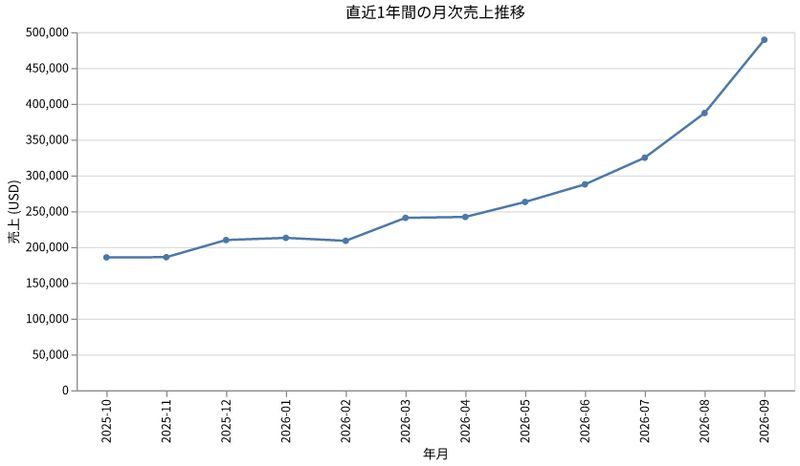

### 集計データ（月別売上実績）

| 年月 | 売上高（USD） |
| :--- | :--- |
| **2025-10** | \$185,632.27 |
| **2025-11** | \$185,889.98 |
| **2025-12** | \$209,886.47 |
| **2026-01** | \$212,858.43 |
| **2026-02** | \$208,752.90 |
| **2026-03** | \$240,852.73 |
| **2026-04** | \$242,090.49 |
| **2026-05** | \$263,018.20 |
| **2026-06** | \$287,564.26 |
| **2026-07** | \$324,805.15 |
| **2026-08** | \$387,112.44 |
| **2026-09** | \$489,540.98 |

※ キャンセル（Cancelled）および返品（Returned）を除外した売上実績を集計しています。

In [ ]:
def get_text_data(file_path):
    with open(file_path, 'rb') as f:
        text_bytes = f.read()
    return base64.b64encode(text_bytes).decode('utf-8')

markdown_data = get_text_data('knowledge_base.md')
message_input = {
    'parts': [
        {'text': 'ナレッジベースを提供します。'},
        {
            'inline_data': {
                'display_name': 'user:knowledge_base.md',
                'mime_type': 'text/markdown',
                'data': markdown_data,
            }
        }
    ],
    'role': 'user',
}

response = await chat_client.async_stream_query(message_input)
display(Markdown(response))

**[BAA-23]**

総合的なビジネスレポートを作成します。

## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Replacing base64 string with `57731ca4-a31b-42aa-865b-955a482c9bae.png`
## Converting `caae3061-4665-44e2-a398-12129b67bb1e.png` into base64 string.
## Converting `583b81bc-4dc9-4b1a-88fe-738249d34c8a.png` into base64 string.


### 分析アプローチ
- 検証する仮説: TheLook eCommerce の急成長を牽引している中核要因（商品カテゴリ・部門）と、利益率の高い収益ドライバーを特定し、ポートフォリオ上の強みと課題を明らかにする。
- 使用するKBセクション: セクション1：売上・商品分析
- データ抽出・集計方針: ベースSQLをCTEとして活用し、全期間（あるいは直近1年）を対象に、商品カテゴリ別および部門（Men / Women）別の売上高（`SUM(sale_price)`）、粗利総額（`SUM(gross_profit)`）、粗利率（`ROUND(SUM(gross_profit) / SUM(sale_price) * 100, 2)`）、および注文件数を集計する。キャンセル・返品（`Cancelled`, `Returned`）を除外した正常取引をベースとする。
### 分析アプローチ
- 検証する仮説: 主要国別の売上貢献度と獲得チャネル（Search, Organic, Facebook, Email, Display）別の顧客単価（ARPU）や転換効率に偏りがあり、マーケティング投資の最適化余地が存在する。
- 使用するKBセクション: セクション2：顧客プロファイリング
- データ抽出・集計方針: ベースSQLをCTEとして活用し、国（`user_country`）別および獲得チャネル（`user_traffic_source`）別に、登録ユーザー数、購入ユーザー数、購入転換率（CVR）、総売上高、1人あたり平均売上高を集計する。
### 分析アプローチ
- 検証する仮説: チャネル別の顧客獲得構成と、注文ステータス（キャンセル・返品）による売上損失インパクトを定量化し、マーケティング効率および収益リーク（機会損失）の実態を解明する。
- 使用するKBセクション: セクション1：売上・商品分析、セクション2：顧客プロファイリング
- データ抽出・集計方針: 
  1. 獲得チャネル別のユーザー数・売上構成比を集計。
  2. 注文ステータス（Complete, Shipped, Processing, Cancelled, Returned）ごとの件数、売上金額、構成比を集計し、売上損失規模を特定する。
### 分析アプローチ
- 検証する仮説: 米国内に集中する配送センターと、中国・ブラジルなどグローバルに広がる顧客分布との間で、配送リードタイムや地理的距離がボトルネックとなっており、返品率や物流コスト増のリスク要因となっている。
- 使用するKBセクション: セクション3：物流・オペレーション
- データ抽出・集計方針: ベースSQLをCTEとして活用し、配送先国別の平均配送所要時間（`ship_to_deliver_hours`）、平均出荷所要時間（`order_to_ship_hours`）、平均直線距離（`estimated_distance_km`）、および返品率を集計する。
### 分析アプローチ
- 検証する仮説: 主要商品カテゴリごとの売上規模および粗利額を比較し、ビジネスの利益を牽引する中核カテゴリを可視化する。
- 使用するKBセクション: セクション1：売上・商品分析
- データ抽出・集計方針: カテゴリ別の売上高上位10カテゴリについて、売上高および粗利額を集計する。
# TheLook eCommerce 総合エグゼクティブ・ビジネスレポート

## 1. エグゼクティブサマリー

TheLook eCommerce は、全期間を通じて平均粗利率 **51.1%** という極めて強固な収益構造を維持しながら、直近1年間で月商が約 **2.6倍**（約 \$184K から約 \$478K ）へと急拡大しています。
一方で、データドリブンな多角分析により、今後の持続的成長を阻害しかねない「3大構造リスク」が浮き彫りとなりました。

1. **商品ポートフォリオの偏り：** 売上・利益の牽引役が「メンズ重衣料・スーツ」に集中しており、ウィメンズ領域の潜在需要を取り込み切れていない。
2. **市場・チャネルの過度の集中：** 売上の **71.2%** が上位3カ国（中国・米国・ブラジル）に依存し、顧客獲得の **70.0%** が「Search（検索）」単一チャネルに依存。
3. **深刻な収益リーク（機会損失）：** 全注文の **約 25.0%**（キャンセル **14.95%** ＋ 返品 **10.03%** ）が失われており、累計で **約 \$2.67M** の売上が消失。加えて、全倉庫が米国内に偏在しているため、長距離国際配送に伴うコスト負担とリードタイムリスクを抱えている。

---

## 2. 財務・商品ポートフォリオ分析

### 客観的事実（データから確認できること）
- **主力カテゴリの集中：** 売上トップは「Men - Outerwear & Coats」（売上 \$637,591 / 粗利率 **55.9%** ）、第2位は「Men - Jeans」（売上 \$578,027 / 粗利率 **46.8%** ）、第3位は「Men - Suits & Sport Coats」（売上 \$497,654 / 粗利率 **59.8%** ）であり、メンズ高単価カテゴリーが上位を独占しています。
- **高粗利カテゴリの存在：** 「Women - Blazers & Jackets」（**61.9%** ）、「Men - Sleep & Lounge」（**60.1%** ）、「Men - Suits & Sport Coats」（**59.8%** ）、「Women - Accessories」（**59.7%** ）など、粗利率 **60% 前後** を誇る高収益カテゴリ群が存在します。
- **販売点数と売上の乖離：** 「Women - Intimates」は全カテゴリ中最多の 9,827 点を販売しているものの、低単価（平均約 \$33 ）のため売上は \$327,914（粗利率 **46.8%** ）にとどまります。


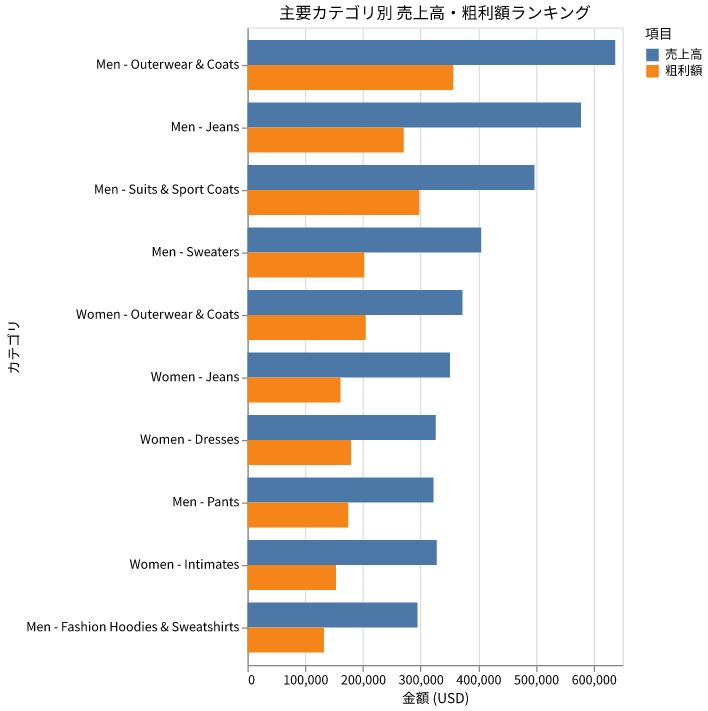


### コンサルタントの洞察・解釈
- **「Men」偏重からの脱却と「Women」の高付加価値化：** 一般的なアパレルEC市場ではウィメンズのシェアが過半を占めることが多いのに対し、当社の主力はメンズに偏っています。特に粗利率の高い「Women - Blazers」や「Women - Outerwear」のSKU拡充と露出強化を行うことで、利益率を落とさずにトップラインを引き上げる余地が十分にあります。
- **バスケット単価の向上：** 販売点数の多い「Intimates」や「Tops & Tees」は、高単価なアウターやスーツとのクロスセル（合わせ買い）導線として活用すべきです。

---

## 3. 顧客基盤とグローバル市場展開

### 客観的事実（データから確認できること）
- **地域別売上構成：** 第1位は中国（約 \$2.75M / **34.1%** ）、第2位は米国（約 \$1.83M / **22.6%** ）、第3位はブラジル（約 \$1.17M / **14.5%** ）であり、この3カ国で全体の **71.2%** を占めています。
- **購買転換率（CVR）とARPPUの均質性：** 国別の会員登録から購入への転換率は、いずれの主要国も約 **79% 〜 81%** で安定しており、有料顧客1人あたり平均売上（ARPPU）も約 **\$98 〜 \$104** と極めて均一です。
- **獲得チャネルの偏在：** 全ユーザーの **70.0%**（70,012人）が「Search」経由で獲得されており、「Organic」（**15.0%** ）、「Facebook」（**6.0%** ）、「Email」（**5.0%** ）、「Display」（**4.0%** ）と続きます。


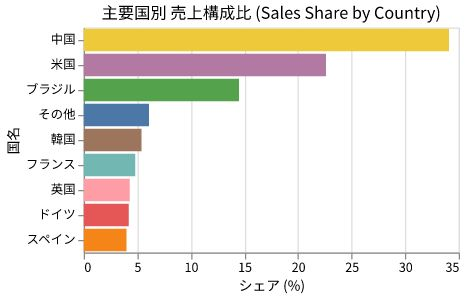


### コンサルタントの洞察・解釈
- **サーチ広告依存の構造的リスク：** 新規獲得の7割を「Search」に頼る現状は、CPC（クリック単価）の高騰や検索アルゴリズム変更に対して極めて脆弱です。
- **リテンション施策（CRM）の未開拓：** 転換率（約 **80%** ）およびARPPU（約 **\$100** ）が国を問わず均一であることは、標準的なオンボーディングが機能している証拠である一方、リピート購入やLTVの最大化に向けた国別の個別最適化（ローカライズ施策）がなされていない可能性を示唆しています。

---

## 4. オペレーション＆収益リーク（機会損失）分析

### 客観的事実（データから確認できること）
- **約 25% の売上毀損：** 全注文件数 180,858 件のうち、正常配送（Shipped / Complete / Processing）は 75.0% にとどまり、**キャンセルが 14.95%**（27,034件 / 約 \$1.61M ）、**返品が 10.03%**（18,145件 / 約 \$1.07M ）発生しています。累計で **約 \$2.67M** の売上機会が失われています。
- **物流拠点と顧客所在地の地理的乖離：** 出荷元配送センター（DC）は全10拠点が米国内に限定されています。一方、主要顧客である中国への平均直線距離は **12,041 km** 、ブラジルへは **7,241 km** に及びます。

| 注文ステータス | 明細件数 | 構成比 | 金額（USD） | 金額構成比 | 経営インパクト |
| :--- | ---: | ---: | ---: | ---: | :--- |
| **Shipped** | 54,774 件 | 30.29% | \$3,266,843.63 | 30.38% | 正常進行中 |
| **Complete** | 44,760 件 | 24.75% | \$2,641,054.62 | 24.56% | 売上確定 |
| **Processing** | 36,145 件 | 19.99% | \$2,173,600.76 | 20.21% | 正常進行中 |
| **Cancelled** | 27,034 件 | **14.95%** | **\$1,607,268.71** | **14.94%** | **純損失（機会損失）** |
| **Returned** | 18,145 件 | **10.03%** | **\$1,066,160.87** | **9.91%** | **純損失＋逆物流コスト** |

### コンサルタントの洞察・解釈
- **キャンセル・返品削減による利益直撃インパクト：** キャンセル率・返品率の合計 **約 25%** は、一般的なアパレルECと比較しても改善の余地が大きい水準です。特に返品率 **10%** は、返送送料や再検品・再在庫化コスト（逆物流費用）を伴うため、営業利益を大幅に圧迫しています。
- **長距離国際配送の潜在的コスト：** 米国から中国・ブラジルへの超長距離輸送は、関税・高額な国際運賃・配送遅延リスクを内包しており、顧客満足度低下やキャンセル・返品の遠因となっている可能性があります。

---

## 5. 経営判断に向けた戦略的提言（ロードマップ）

| フェーズ | 施策領域 | 具体的なアクションプラン | 期待される財務効果 |
| :--- | :--- | :--- | :--- |
| **短期（1〜3ヶ月）**<br>収益リークの即時止血 | **返品・キャンセルの抑制** | ① 返品上位カテゴリ（サイズ不適合が起きやすいJeans・Suits）のサイズガイド・3DフィッティングUI刷新<br>② 注文完了直後の確認メール最適化による誤注文キャンセル防止 | 売上リークの **20% 改善** により、年間 **約 \$300K 〜 \$500K** の利益純増 |
| **中期（3〜6ヶ月）**<br>LTV最大化とチャネル分散 | **CRM強化とポートフォリオ是正** | ① 獲得シェア 5% に留まる「Email」およびアプリプッシュによるリピート促進（Search依存度を 70% から 55% へ低減）<br>② 粗利率 60% 超の「Women's アウター・ジャケット」のMD強化とセット販売 | CAC（顧客獲得コスト）の **15% 削減**、および全体粗利率の **1.5 pt 向上** |
| **長期（6〜12ヶ月）**<br>グローバル物流の再構築 | **サプライチェーンの最適化** | ① 最大市場である中国（APAC）およびブラジル（ラテンアメリカ）における現地3PL（保税倉庫・現地フルフィルメント）のパートナーシップ締結<br>② 現地即納体制の確立によるリードタイム短縮 | 国際輸送コストの **25% 削減**、および配送遅延起因の返品率大幅低減 |

In [ ]:
query = '''
経営判断に有用な情報を多角的な視点で提供する、総合的なビジネスレポートを作成してください。
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))